In [ ]:
!pip install imbalanced-learn torch_geometric
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.nn import GATv2Conv, AttentionalAggregation, BatchNorm, GraphSizeNorm
from torch_geometric.data import Data
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# --- CONFIGURATION ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_NODES = 116
PCA_DIM = 32
CUSTOM_SAMPLING = {0: 81, 1: 82, 2: 83, 3: 81}
CLASS_NAMES = ['AD', 'LMCI', 'EMCI', 'CN']

print(f"Using device: {DEVICE}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.0 MB/s eta 0:00:00
Using device: cuda


# Multi-Modal Data Handling

In [ ]:
class MultiModalBatch:
    """
    Collate object to manage triple-topology graphs.
    It ensures that edge indices are offset correctly during batching.
    """
    def __init__(self, data_list):
        # Concatenate node features, labels, and global vector features
        self.x = torch.cat([d.x for d in data_list], dim=0)
        self.y = torch.cat([d.y for d in data_list], dim=0)
        self.extra_feat = torch.cat([d.extra_feat for d in data_list], dim=0)

        # Track which node belongs to which graph in the batch
        self.batch = torch.cat([torch.full((d.num_nodes,), i, dtype=torch.long)
                               for i, d in enumerate(data_list)], dim=0)

        curr_n = 0
        e_p, e_g, e_w = [], [], []

        # Offset edge indices for global batching (Pearson, Granger, Wavelet)
        for d in data_list:
            e_p.append(d.edge_index + curr_n)
            e_g.append(d.edge_granger + curr_n)
            e_w.append(d.edge_wavelet + curr_n)
            curr_n += d.num_nodes

        self.edge_index = torch.cat(e_p, dim=1)
        self.edge_granger = torch.cat(e_g, dim=1)
        self.edge_wavelet = torch.cat(e_w, dim=1)

    def to(self, device):
        """Standard method to move the whole batch to GPU."""
        self.x, self.y, self.batch = self.x.to(device), self.y.to(device), self.batch.to(device)
        self.edge_index = self.edge_index.to(device)
        self.edge_granger = self.edge_granger.to(device)
        self.edge_wavelet = self.edge_wavelet.to(device)
        self.extra_feat = self.extra_feat.to(device)
        return self

# Neural Network Model

In [ ]:
class NeuroVistaPrecisionNet(torch.nn.Module):
    """
    Triple-Stream GATv2 model.
    Learns patterns from Pearson Correlation, Granger Causality, and Wavelet Coherence.
    """
    def __init__(self, node_in, vector_in):
        super().__init__()

        # Parallel Attention Streams: 8 heads per stream for rich feature extraction
        self.gat_p = GATv2Conv(node_in, 64, heads=8, concat=True, dropout=0.1) # Pearson
        self.gat_g = GATv2Conv(node_in, 64, heads=8, concat=True, dropout=0.1) # Granger
        self.gat_w = GATv2Conv(node_in, 64, heads=8, concat=True, dropout=0.1) # Wavelet

        # Normalization to stabilize training across different graph sizes
        self.gnorm = GraphSizeNorm()
        self.bn = BatchNorm(512)

        # Attentional Pooling: Learns which brain regions are most important for classification
        self.pool = AttentionalAggregation(nn.Sequential(nn.Linear(512, 1)))

        # Final Deep Classifier: Fuses graph features with global vector features
        self.classifier = nn.Sequential(
            nn.Linear(512*3 + vector_in, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.45), # Prevents overfitting
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 4) # 4 output classes (AD, LMCI, EMCI, CN)
        )

    def forward(self, data):
        # Process the three connectivity streams through GAT + Normalization
        p = F.elu(self.bn(self.gnorm(self.gat_p(data.x, data.edge_index), data.batch)))
        g = F.elu(self.bn(self.gnorm(self.gat_g(data.x, data.edge_granger), data.batch)))
        w = F.elu(self.bn(self.gnorm(self.gat_w(data.x, data.edge_wavelet), data.batch)))

        # Concatenate pooled features and the extra normalized vector features
        pooled = torch.cat([
            self.pool(p, data.batch),
            self.pool(g, data.batch),
            self.pool(w, data.batch),
            data.extra_feat
        ], dim=1)

        return self.classifier(pooled)

# Data Processing Pipeline

In [ ]:
def load_dataset(base_path):
    """Reads .npy files, balances classes with SMOTE, and prepares PyG objects."""
    X_raw, y_raw = [], []
    class_map = {'AD_graphs': 0, 'LMCI_graphs': 1, 'EMCI_graphs': 2, 'CN_graphs': 3}

    # 1. Load data from disk
    for folder, val in class_map.items():
        p_path = f"{base_path}/{folder}/Graph_Output"
        if not os.path.exists(p_path): continue
        for f in os.listdir(p_path):
            sid = f.replace('_corr_matrix.npy', '')
            try:
                p = np.load(f"{p_path}/{f}") # Pearson
                g = np.load(f"{base_path}/{folder}/Graph_Output_Granger/{sid}_granger_matrix.npy") # Granger
                w = np.load(f"{base_path}/{folder}/Graph_Output_Coherence/{sid}_coherence_matrix.npy") # Wavelet
                X_raw.append(np.hstack([p.flatten(), g.flatten(), w.flatten()]))
                y_raw.append(val)
            except: continue

    # 2. Oversampling to fix class imbalance
    X_raw, y_raw = np.array(X_raw), np.array(y_raw)
    sm = SMOTE(sampling_strategy=CUSTOM_SAMPLING, random_state=42)
    X_res, y_res = sm.fit_resample(X_raw, y_raw)

    # 3. Scale global features for the Neural Network
    scaler = StandardScaler()
    X_norm = scaler.fit_transform(X_res)

    # 4. Convert matrices into Graph Objects
    size, ds = NUM_NODES * NUM_NODES, []
    for i in range(len(y_res)):
        p_mat = X_res[i, :size].reshape(NUM_NODES, NUM_NODES)
        g_mat = X_res[i, size:2*size].reshape(NUM_NODES, NUM_NODES)
        w_mat = X_res[i, 2*size:].reshape(NUM_NODES, NUM_NODES)

        # Thresholding: only keep edges in the top 15% of strength (85th percentile)
        t = np.percentile(np.abs(p_mat), 85)

        ds.append(Data(
            x=torch.tensor(p_mat[:, :PCA_DIM], dtype=torch.float),
            edge_index=torch.tensor(np.argwhere(np.abs(p_mat) > t).T, dtype=torch.long),
            edge_granger=torch.tensor(np.argwhere(np.abs(g_mat) > t).T, dtype=torch.long),
            edge_wavelet=torch.tensor(np.argwhere(np.abs(w_mat) > t).T, dtype=torch.long),
            y=torch.tensor([y_res[i]], dtype=torch.long),
            extra_feat=torch.tensor(X_norm[i, :1024], dtype=torch.float).view(1, -1),
            num_nodes=NUM_NODES
        ))
    return ds, scaler

# Execution and Evaluation

Starting 5-Fold Cross-Validation...
Fold 1 Complete.
Fold 2 Complete.
Fold 3 Complete.
Fold 4 Complete.
Fold 5 Complete.

OVERALL SYSTEM ACCURACY: 74.31%
------------------------------------------------------------
              precision    recall  f1-score   support

          AD       0.75      0.73      0.74        81
        LMCI       0.70      0.98      0.82        82
        EMCI       0.82      0.81      0.81        83
          CN       0.71      0.46      0.56        81

    accuracy                           0.74       327
   macro avg       0.74      0.74      0.73       327
weighted avg       0.74      0.74      0.73       327



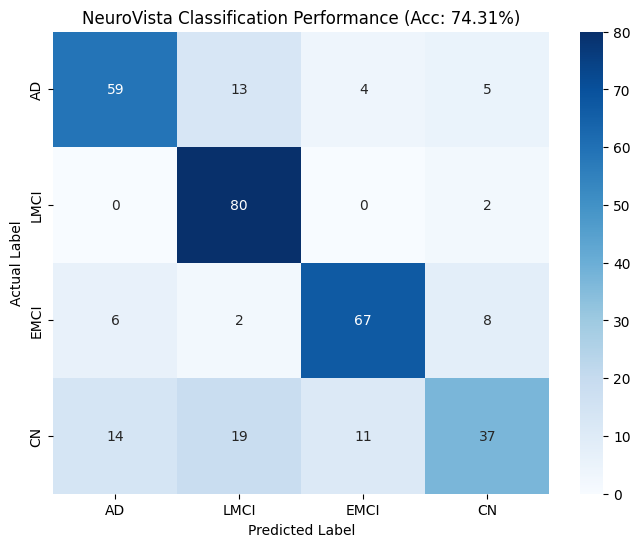

In [ ]:
# --- EXECUTION & EVALUATION ---

# Update this path to your actual folder location
BASE_PATH = "/content/drive/MyDrive/NEUROVISTA-PROJECT/All_GRAPHS_Unzipped"

def run_analysis():
    # 1. Load and Preprocess Data
    dataset, scaler = load_dataset(BASE_PATH)
    labels = [d.y.item() for d in dataset]

    # 2. Setup Stratified K-Fold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    all_preds, all_labels = [], []

    print("Starting 5-Fold Cross-Validation...")

    # 3. Cross-Validation Loop
    for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(dataset)), labels)):
        # Create DataLoaders for this fold
        train_loader = DataLoader([dataset[i] for i in train_idx], batch_size=8, shuffle=True, collate_fn=MultiModalBatch)
        test_loader = DataLoader([dataset[i] for i in test_idx], batch_size=1, collate_fn=MultiModalBatch)

        # Initialize Model, Optimizer, and Scheduler
        model = NeuroVistaPrecisionNet(PCA_DIM, 1024).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1.2e-4, weight_decay=0.04)
        scheduler = OneCycleLR(optimizer, max_lr=5e-4, steps_per_epoch=len(train_loader), epochs=100)

        # Training Loop
        for epoch in range(100):
            model.train()
            for batch in train_loader:
                batch = batch.to(DEVICE)
                optimizer.zero_grad()

                # Forward Pass
                out = model(batch)
                loss = F.cross_entropy(out, batch.y, label_smoothing=0.04)

                # Backward Pass
                loss.backward()
                optimizer.step()
                scheduler.step()

        # Validation Loop
        model.eval()
        with torch.no_grad():
            for batch in test_loader:
                # Get prediction and store results
                pred = model(batch.to(DEVICE)).argmax(1).item()
                all_preds.append(pred)
                all_labels.append(batch.y.item())

        print(f"Fold {fold+1} Complete.")

    # 4. Results Reporting
    acc = accuracy_score(all_labels, all_preds) * 100
    print(f"\nOVERALL SYSTEM ACCURACY: {acc:.2f}%")
    print("-" * 60)
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

    # 5. Confusion Matrix Visualization
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'NeuroVista Classification Performance (Acc: {acc:.2f}%)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # --- THE CRITICAL FIX: RETURN THE OBJECTS ---
    return model, scaler

# Execute the pipeline and capture the objects for saving/exporting
model, scaler = run_analysis()

# Save Model

In [ ]:
import joblib
import os

# 1. Setup the folder path in your Drive
SAVE_PATH = "/content/drive/MyDrive/NEUROVISTA-PROJECT/Neurovista4ClassModel"
os.makedirs(SAVE_PATH, exist_ok=True)

# 2. Save the Model (the .pth file)
model_file = f"{SAVE_PATH}/neurovista_model.pth"
torch.save(model.state_dict(), model_file)

# 3. Save the Scaler (the .pkl file)
scaler_file = f"{SAVE_PATH}/scaler.pkl"
joblib.dump(scaler, scaler_file)

print("-" * 30)
print(f"✅ SUCCESS: Files are now permanent!")
print(f"Model: {model_file}")
print(f"Scaler: {scaler_file}")
print("-" * 30)



------------------------------
✅ SUCCESS: Files are now permanent!
Model: /content/drive/MyDrive/NEUROVISTA-PROJECT/Neurovista4ClassModel/neurovista_model.pth
Scaler: /content/drive/MyDrive/NEUROVISTA-PROJECT/Neurovista4ClassModel/scaler.pkl
------------------------------


In [ ]:
# # Optional: Download them to your computer's "Downloads" folder immediately
# from google.colab import files
# files.download(model_file)
# files.download(scaler_file)